In [1]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import keras
from keras import optimizers
#from keras.preprocessing.image import ImageDataGenerator, load_img, image
#from keras.preprocessing.image import load_img, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

In [2]:
import os
import pandas as pd

train_dir = 'train_256/'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(train_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['1' if f.endswith('yellow1.png') else '0' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
df.head()

(432, 2)


,filename,category
0,m05_tile256_x03328_y00512_yellow0.png,0
1,m05_tile256_x02560_y00000_yellow1.png,1
2,m05_tile256_x01280_y01280_yellow1.png,1
3,m05_tile256_x01024_y03328_yellow0.png,0
4,m05_tile256_x01280_y00256_yellow0.png,0


### see samples

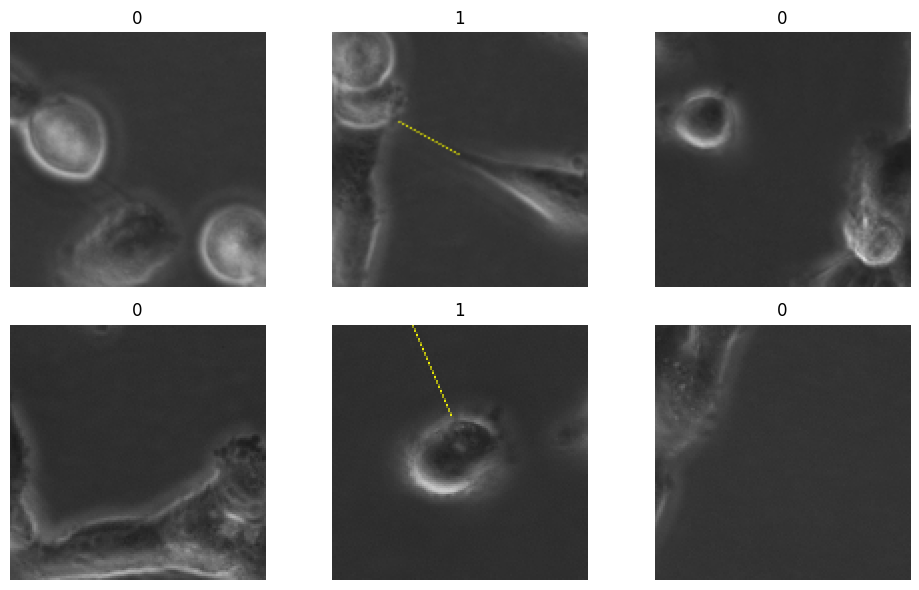

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Build model

In [7]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

INPUT_SHAPE = (178, 218, 3)

class_mode="binary"

# VGG16 base
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze last two layers with weights
unfroze = 0
for layer in reversed(vgg_base.layers):
    if layer.weights:
        layer.trainable = True
        unfroze += 1
        if unfroze == 2:
            break

# Verify trainability
for i, layer in enumerate(vgg_base.layers):
    print(f"{i:02d} {layer.name:25s} trainable={layer.trainable}")

# Explicit input layer
# 'This makes the model immediately callable and avoids a lot of “undefined output” issues.'
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization

INPUT_SHAPE = (178, 218, 3)


# Build Sequential model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")   # categorical output
])

# Callbacks
earlystop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model.celeb_man_female.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

00 input_layer               trainable=False
01 block1_conv1              trainable=False
02 block1_conv2              trainable=False
03 block1_pool               trainable=False
04 block2_conv1              trainable=False
05 block2_conv2              trainable=False
06 block2_pool               trainable=False
07 block3_conv1              trainable=False
08 block3_conv2              trainable=False
09 block3_conv3              trainable=False
10 block3_pool               trainable=False
11 block4_conv1              trainable=False
12 block4_conv2              trainable=False
13 block4_conv3              trainable=False
14 block4_pool               trainable=False
15 block5_conv1              trainable=False
16 block5_conv2              trainable=True
17 block5_conv3              trainable=True
18 block5_pool               trainable=False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,966,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,681,537 (63.64 MB)

 Trainable params: 6,686,209 (25.51 MB)

 Non-trainable params: 9,995,328 (38.13 MB)

# Data Prep

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1) Train/Validation split (20% validation)
train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]  # keeps class balance consistent
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

print("\nTrain class counts:")
print(train_df["category"].value_counts())

print("\nValid class counts:")
print(valid_df["category"].value_counts())

# 2) Batch size
BATCH_SIZE = 20

# 3) Image generators (use VGG16 preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 4) Flow from dataframe
TARGET_SIZE = (178, 218)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_dir,
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",      # two classes -> simplest
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=train_dir,
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nclass_indices:", train_generator.class_indices)

# 5) Steps per epoch / validation steps
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = valid_generator.n // valid_generator.batch_size

# If you want to ensure you don't drop the last partial batch, use ceil:
# import math
# steps_per_epoch = math.ceil(train_generator.n / train_generator.batch_size)
# validation_steps = math.ceil(valid_generator.n / valid_generator.batch_size)

print("\nsteps_per_epoch:", steps_per_epoch)
print("validation_steps:", validation_steps)


Train shape: (345, 2)
Valid shape: (87, 2)

Train class counts:
category
0    301
1     44
Name: count, dtype: int64

Valid class counts:
category
0    76
1    11
Name: count, dtype: int64
Found 345 validated image filenames belonging to 2 classes.
Found 87 validated image filenames belonging to 2 classes.

class_indices: {'0': 0, '1': 1}

steps_per_epoch: 17
validation_steps: 4


# Train

In [9]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[earlystop, checkpoint],
    verbose=1
)

Epoch 1/30


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5812 - loss: 0.8030
Epoch 1: val_loss improved from inf to 0.26595, saving model to model.celeb_man_female.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5831 - loss: 0.7995 - val_accuracy: 0.9000 - val_loss: 0.2660
Epoch 2/30
 1/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7000 - loss: 0.5506

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 0.26595
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 443ms/step - accuracy: 0.7000 - loss: 0.5506 - val_accuracy: 0.9000 - val_loss: 0.2726
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8081 - loss: 0.4080
Epoch 3: val_loss improved from 0.26595 to 0.14292, saving model to model.celeb_man_female.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.8105 - loss: 0.4060 - val_accuracy: 0.9750 - val_loss: 0.1429
Epoch 4/30
 1/17 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7000 - loss: 0.4670
Epoch 4: val_loss did not improve from 0.14292
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 359ms/step - accuracy: 0.7000 - loss: 0.4670 - val_accuracy: 0.9625 - val_loss: 0.1494
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9459 - loss: 0.1839
Epoch 5: val_loss improved from 0.14292 to 0.05243, saving model to model.celeb_man_female.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9442 - loss: 0.1879 - val_accuracy: 0.9875 - val_loss: 0.05

In [10]:
# Save model
model.save("model.celeb_man_female.keras")

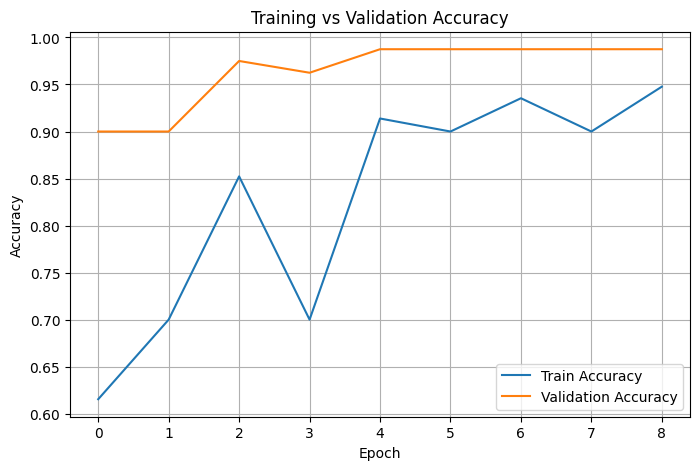

In [11]:
# Plot Accuracy by Epoch
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# Build dataframe comparing predictions with correctness and confidence
import math
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Make a stable copy in a known order
df_pred = df.copy().reset_index(drop=True)

BATCH_SIZE = 20
TARGET_SIZE = (178, 218)  # must match training

pred_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Important: shuffle=False so predictions line up with df_pred row-for-row
pred_gen = pred_datagen.flow_from_dataframe(
    dataframe=df_pred,
    directory=train_dir,
    x_col="filename",
    y_col="category",     # keep y so we get class_indices and can compute correctness
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",  # OK even if model is softmax; we only use it for labels & class_indices
    shuffle=False
)

steps = math.ceil(pred_gen.n / pred_gen.batch_size)

# Predict
yhat = model.predict(pred_gen, steps=steps, verbose=1)

# Convert model outputs to P(man) robustly:
# - sigmoid model => shape (n,1)
# - softmax model => shape (n,2)
class_indices = pred_gen.class_indices          # e.g. {'female': 0, 'man': 1}
idx_man = class_indices.get("man", 1)           # fallback if keys differ

if yhat.ndim == 2 and yhat.shape[1] == 1:
    # sigmoid
    p_man = yhat[:, 0]
elif yhat.ndim == 2 and yhat.shape[1] == 2:
    # softmax
    p_man = yhat[:, idx_man]
else:
    raise ValueError(f"Unexpected prediction shape: {yhat.shape}")

# Predicted label + confidence
df_pred["p_man"] = p_man
df_pred["p_female"] = 1 - p_man
df_pred["pred_category"] = np.where(df_pred["p_man"] >= 0.5, "1", "0")
df_pred["pred_confidence"] = np.maximum(df_pred["p_man"], df_pred["p_female"])

# Compare to actual
df_pred["correct"] = (df_pred["pred_category"] == df_pred["category"]).astype(int)

# Quick summary
print(df_pred[["category", "pred_category", "correct"]].value_counts())
print("Accuracy:", df_pred["correct"].mean())

df_pred.head()


Found 432 validated image filenames belonging to 2 classes.


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
category  pred_category  correct
0         0              1          377
1         1              1           54
          0              0            1
Name: count, dtype: int64
Accuracy: 0.9976851851851852


,filename,category,p_man,p_female,pred_category,pred_confidence,correct
0,m05_tile256_x03328_y00512_yellow0.png,0,0.011740,0.988260,0,0.988260,1
1,m05_tile256_x02560_y00000_yellow1.png,1,1.000000,0.000000,1,1.000000,1
2,m05_tile256_x01280_y01280_yellow1.png,1,1.000000,0.000000,1,1.000000,1
3,m05_tile256_x01024_y03328_yellow0.png,0,0.003372,0.996628,0,0.996628,1
4,m05_tile256_x01280_y00256_yellow0.png,0,0.000381,0.999619,0,0.999619,1


In [14]:
df_pred['correct'].value_counts()

correct
1    431
0      1
Name: count, dtype: int64

# Most confident incorrec tprediction

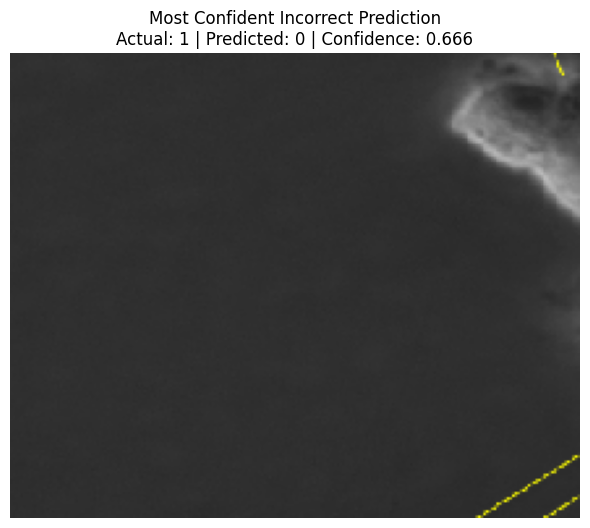

In [15]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import os

# Recompute the row explicitly
row = (
    df_pred[df_pred["correct"] == 0]
    .sort_values("pred_confidence", ascending=False)
    .iloc[0]
)

img_path = os.path.join(train_dir, row["filename"])
img = load_img(img_path, target_size=(178, 218))

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Most Confident Incorrect Prediction\n"
    f"Actual: {row['category']} | "
    f"Predicted: {row['pred_category']} | "
    f"Confidence: {row['pred_confidence']:.3f}"
)
plt.tight_layout()
plt.show()
